<a href="https://colab.research.google.com/github/Alchwalch/Deep-Learning-Study/blob/main/Image%20Detection/AlexNet_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import Subset,DataLoader
from tqdm import tqdm

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
epochs=10
learning_rate=1e-3
batch_size=64
best_acc=0
device='cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
class PCAColorAugmentation(object):
    def __init__(self, std=0.1):
        self.std = std

    def __call__(self, img):
        img = img.permute(1, 2, 0)  # (H, W, C)
        H, W, C = img.shape
        pixels = img.reshape(-1, 3)  # (H*W, C=3)

        cov = torch.cov(pixels.T)
        eigenvalues, eigenvectors = torch.linalg.eigh(cov)

        alphas = torch.normal(0, self.std, size=(3,))
        delta = eigenvectors @ (alphas * eigenvalues)

        img = img + delta
        img = img.clamp(0, 1)
        return img.permute(2, 0, 1)  # (C, H, W)

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    PCAColorAugmentation(std=0.1),
])

transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

#train_subset = Subset(train_dataset)
test_subset = Subset(test_dataset, range(1000))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

In [ ]:
class Seq2(nn.Module):
  def __init__(self,device='cpu'):
    super(Seq2,self).__init__()
    self.device=device
    self.seq2 = nn.Sequential(
        nn.Conv2d(48, 128, kernel_size=5, padding=2),
        nn.ReLU(),
        nn.LocalResponseNorm(5, alpha=1e-4, beta=0.75, k=2.0),
        nn.MaxPool2d(kernel_size=3, stride=2)
    )

  def forward(self,x):
    return self.seq2(x)

In [ ]:
class Seq4(nn.Module):
  def __init__(self,device='cpu'):
    super(Seq4,self).__init__()
    self.device=device
    self.seq4 = nn.Sequential(
        nn.Conv2d(192, 192, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(192, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2)
    )

  def forward(self,x):
    return self.seq4(x)

In [ ]:
class AlexNet(nn.Module):
  def __init__(self, output_size=1000,device='cpu'):
    super(AlexNet,self).__init__()
    self.device=device

    # seq1
    self.seq1 = nn.Sequential(
        nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0),
        nn.ReLU(),
        nn.LocalResponseNorm(5, alpha=1e-4, beta=0.75, k=2.0),
        nn.MaxPool2d(kernel_size=3, stride=2)
    )

    # seq2_1, seq2_2
    self.seq2_1 = Seq2(device=device)
    self.seq2_2 = Seq2(device=device)

    # seq3
    self.seq3 = nn.Sequential(
        nn.Conv2d(256, 384, kernel_size=3, padding=1),
        nn.ReLU()
    )

    # seq4_1, seq4_2
    self.seq4_1 = Seq4(device=device)
    self.seq4_2 = Seq4(device=device)

    # seq5
    self.seq5 = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(9216, 4096),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(4096, 4096),
        nn.ReLU(),
        nn.Linear(4096, output_size)
    )

  def forward(self, x):
    x = self.seq1(x)

    x1 = x[:, :48, :, :]
    x2 = x[:, 48:, :, :]
    x1 = self.seq2_1(x1)
    x2 = self.seq2_2(x2)
    x = torch.cat([x1, x2], dim=1)

    x = self.seq3(x)

    x1 = x[:, :192, :, :]
    x2 = x[:, 192:, :, :]
    x1 = self.seq4_1(x1)
    x2 = self.seq4_2(x2)
    x = torch.cat([x1, x2], dim=1)

    x = x.view(x.size(0), -1)
    x = self.seq5(x)
    return x

In [ ]:
model = AlexNet(output_size=10,device=device)
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

In [ ]:
if os.path.exists('/content/drive/MyDrive/alexnet_best.pth'):
  checkpoint = torch.load('/content/drive/MyDrive/alexnet_best.pth')
  model.load_state_dict(checkpoint['model_state_dict'])
  optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
  best_acc = checkpoint['best_acc']

In [ ]:
train_loss_list = []
test_acc_list = []

In [ ]:
for epoch in range(epochs):
  model.train()
  for x,t in tqdm(train_loader,desc="Batch"):
    x, t = x.to(device), t.to(device)
    optimizer.zero_grad()
    loss = criterion(model(x), t)
    train_loss_list.append(loss.item())
    loss.backward()
    optimizer.step()
  model.eval()
  correct = 0
  with torch.no_grad():
      for x, t in test_loader:
          x, t = x.to(device), t.to(device)
          correct += (model(x).argmax(1) == t).sum().item()

  test_acc=correct/len(test_subset)
  test_acc_list.append(test_acc)
  if test_acc>best_acc:
    best_acc=test_acc
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_acc': best_acc,
    },'/content/drive/MyDrive/alexnet_best.pth')
  print(f'Epoch {epoch+1} | Test Acc: {test_acc:.4f}')


Batch: 100%|██████████| 782/782 [01:51<00:00,  7.02it/s]


Epoch 1 | Test Acc: 0.8350


Batch: 100%|██████████| 782/782 [01:51<00:00,  7.01it/s]


Epoch 2 | Test Acc: 0.8330


Batch: 100%|██████████| 782/782 [01:51<00:00,  7.00it/s]


...

Epoch 8 | Test Acc: 0.8450


Batch: 100%|██████████| 782/782 [01:50<00:00,  7.09it/s]


Epoch 9 | Test Acc: 0.8480


Batch: 100%|██████████| 782/782 [01:49<00:00,  7.12it/s]


Epoch 10 | Test Acc: 0.8350


/tmp/ipykernel_492/1666060049.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/tmp/ipykernel_492/1666060049.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


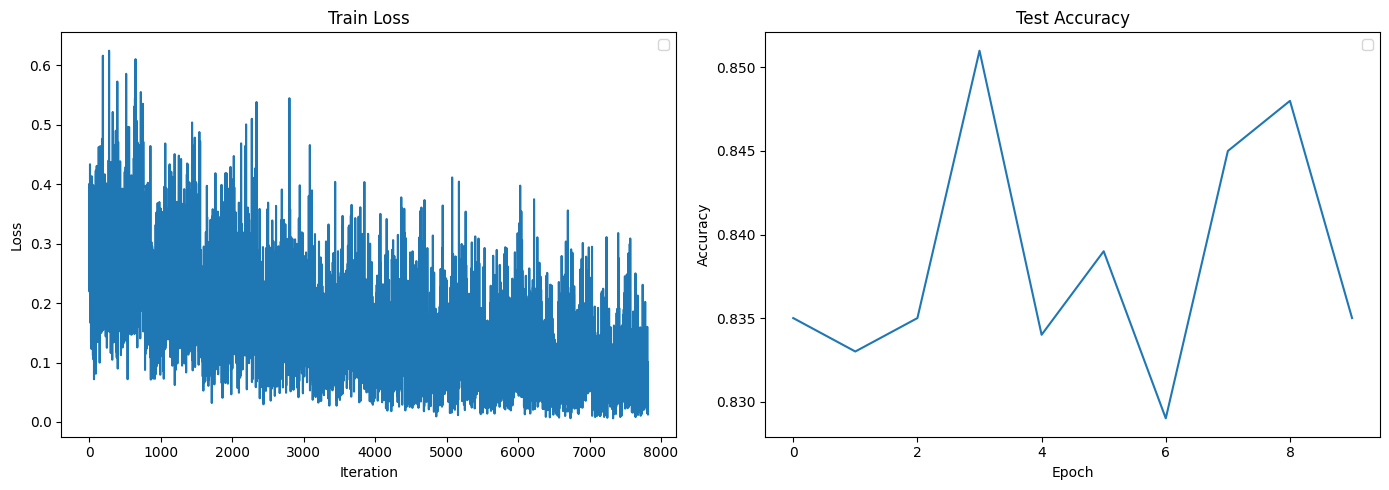

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_loss_list)
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(test_acc_list)
axes[1].set_title("Test Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()